In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


In [6]:
# Load dataset
df = sns.load_dataset("titanic")

# Ukuran data
print("Ukuran data:", df.shape)

# Tipe kolom
print("\nTipe kolom:")
print(df.dtypes)

Ukuran data: (891, 15)

Tipe kolom:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [7]:
# Cek missing value
print("Missing value sebelum:")
print(df.isnull().sum())

# Penanganan missing value:
# age -> median karena numerik dan tahan terhadap outlier
df["age"] = df["age"].fillna(df["age"].median())

# embarked -> modus karena kategorikal dan ambil nilai paling sering
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# embark_town -> modus
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# deck dihapus karena terlalu banyak missing value
df = df.drop(columns=["deck"])

print("\nMissing value sesudah:")
print(df.isnull().sum())

Missing value sebelum:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing value sesudah:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [9]:
# Fungsi IQR
def handle_outlier(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    df[col] = df[col].clip(low, high)

# Tangani outlier age dan fare
handle_outlier("age")
handle_outlier("fare")

print(df[["age", "fare"]].describe())

              age        fare
count  891.000000  891.000000
mean    29.039282   24.046813
std     12.072074   20.481625
min      2.500000    0.000000
25%     22.000000    7.910400
50%     28.000000   14.454200
75%     35.000000   31.000000
max     54.500000   65.634400


In [10]:
# Scaling numerik
scaler = StandardScaler()

df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

print(df[["age", "fare"]].head())

        age      fare
0 -0.583432 -0.820552
1  0.742685  2.031623
2 -0.251903 -0.787578
3  0.494038  1.419297
4  0.494038 -0.781471


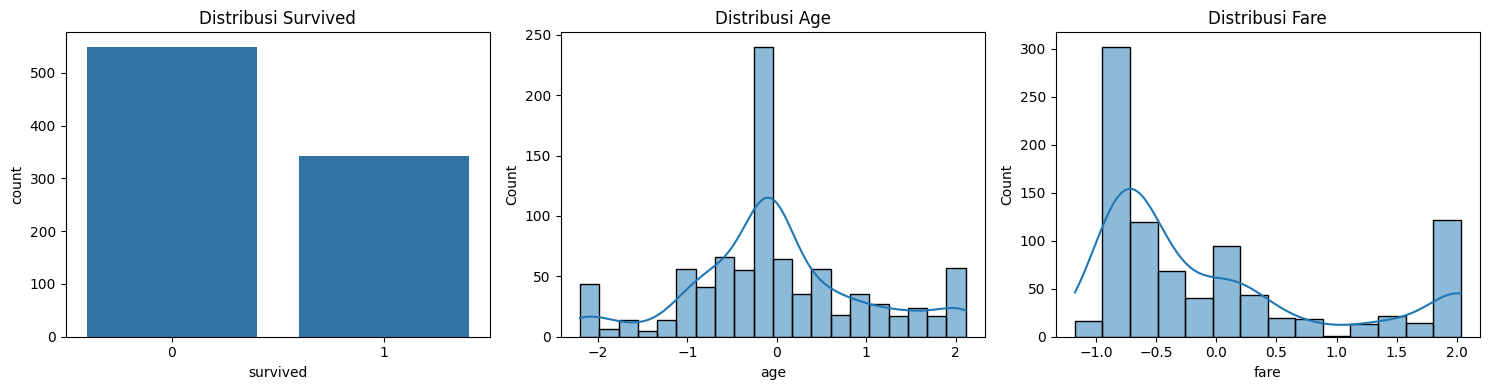

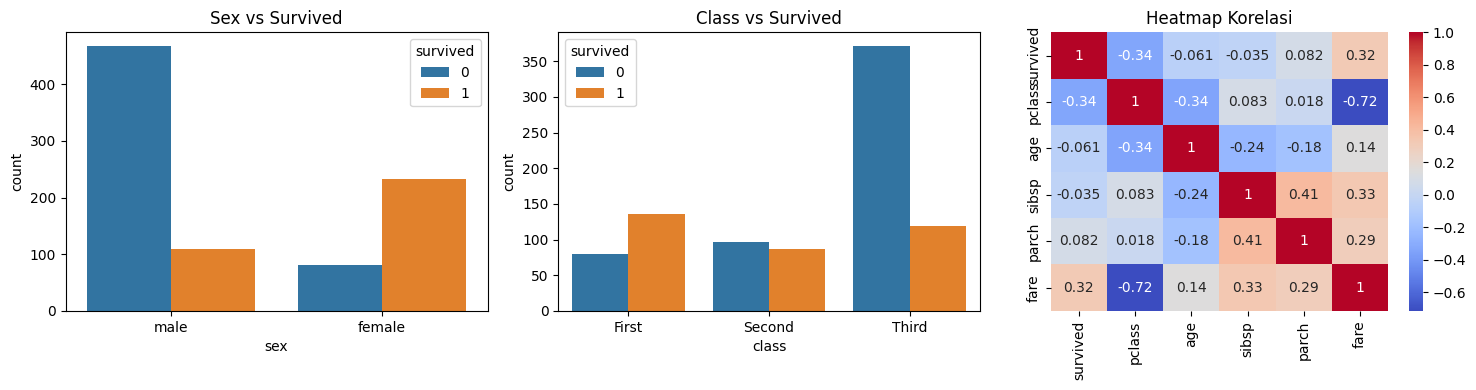


5 Insight:
1. Jumlah penumpang yang tidak selamat lebih banyak daripada yang selamat.
2. Usia penumpang dominan pada kelompok dewasa muda.
3. Fare menunjukkan distribusi tidak merata karena adanya tiket mahal.
4. Penumpang perempuan memiliki tingkat keselamatan lebih tinggi.
5. Penumpang kelas pertama memiliki peluang selamat lebih besar.



In [12]:
plt.figure(figsize=(15,4))

# 1 Distribusi survived
plt.subplot(1,3,1)
sns.countplot(data=df, x="survived")
plt.title("Distribusi Survived")

# 2 Distribusi age
plt.subplot(1,3,2)
sns.histplot(df["age"], kde=True)
plt.title("Distribusi Age")

# 3 Distribusi fare
plt.subplot(1,3,3)
sns.histplot(df["fare"], kde=True)
plt.title("Distribusi Fare")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15,4))

# 4 Sex vs survived
plt.subplot(1,3,1)
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Sex vs Survived")

# 5 Class vs survived
plt.subplot(1,3,2)
sns.countplot(data=df, x="class", hue="survived")
plt.title("Class vs Survived")

# Heatmap korelasi
plt.subplot(1,3,3)
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi")

plt.tight_layout()
plt.show()

# 5 Insight
print("""
5 Insight:
1. Jumlah penumpang yang tidak selamat lebih banyak daripada yang selamat.
2. Usia penumpang dominan pada kelompok dewasa muda.
3. Fare menunjukkan distribusi tidak merata karena adanya tiket mahal.
4. Penumpang perempuan memiliki tingkat keselamatan lebih tinggi.
5. Penumpang kelas pertama memiliki peluang selamat lebih besar.
""")